In [6]:
import torch
import torch.nn as nn
import numpy as np
from ffn import FeedForwardNeuralNetwork

In [7]:
print(torch.__version__)

2.11.0+cpu


## Transform

In [8]:
class MyTransformer(nn.Module):
    def __init__(self, head_num, num_layers, d_model, head_dim, num_embedding, max_seq_len, padding_id):
        super(MyTransformer, self).__init__()
        # 先处理padding_mask
        # padding_id是填充字段的向量id
        self.padding_id = padding_id
        # embedding实例
        self.input_embedding = nn.Embedding(num_embedding, d_model, padding_idx=padding_id)
        self.output_embedding = nn.Embedding(num_embedding, d_model, padding_idx=padding_id)

        self.p_encoding_input = PositionalEncoding(d_model, max_seq_len)
        self.p_encoding_output = PositionalEncoding(d_model, max_seq_len)
        # 堆叠的编码器
        self.encoders = nn.ModuleList([Encoder( head_num, head_dim, d_model ) 
                                       for _ in range(num_layers)])
        self.decoders = nn.ModuleList([Decoder(head_num, head_dim, d_model) 
                                      for _ in range(num_layers)])
        self.linear_layer = nn.Linear(d_model, num_embedding)
        
    def forward(self, input_data, output_data):
        # 处理padding_mask
        input_pad_mask = (input_data != self.padding_id) # 此时结构为[batch_size, src_len]
        input_pad_mask = input_pad_mask.unsqueeze(1).unsqueeze(2) # 扩展
        output_pad_mask = (output_data != self.padding_id)
        output_pad_mask = output_pad_mask.unsqueeze(1).unsqueeze(2) # 扩展
        # embedding
        x = self.input_embedding(input_data)
        y = self.output_embedding(output_data)
        x = self.p_encoding_input(x)
        y = self.p_encoding_output(y)
        # 叠层编码器
        for encoder in self.encoders:
            x = encoder(x, input_pad_mask)
        # 送入解码器
        for decoder in self.decoders:
            y = decoder(y, x, input_pad_mask, output_pad_mask)
        y = self.linear_layer(y)
        
        return y
    

## 编码器(Encoder)

In [9]:
class Encoder(nn.Module):
    def __init__(self, head_num, head_dim, d_model):
        super(Encoder, self).__init__()
        self.multhattention = MultiHeadAttention(head_num, head_dim, d_model)
        self.ffn = FeedForwardNeuralNetwork(d_model)
        self.norm_multhead = nn.LayerNorm(d_model)
        self.norm_fnn = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask):
        temp_x = x
        x = self.multhattention(x, x, x, padding_mask)
        x = x + temp_x
        x = self.norm_multhead(x)

        temp_x = x
        x = self.ffn(x)
        x = x + temp_x
        x = self.norm_fnn(x)
        return x

## 解码器(Decoder)

In [10]:
class Decoder(nn.Module):
    def __init__(self, head_num, head_dim, d_model):
        super(Decoder, self).__init__()
        # 掩码多头注意力模块
        self.masked_multiha = MultiHeadAttention(head_num, head_dim, d_model, masked=True)
        # 交叉注意力模块
        self.crossa = MultiHeadAttention(head_num, head_dim, d_model)
        self.ffn = FeedForwardNeuralNetwork(d_model)
        self.masked_norm = nn.LayerNorm(d_model)
        self.crossa_norm = nn.LayerNorm(d_model)
        self.fnn_norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, input_padding_mask, output_padding_mask):
        # x是output
        temp_x = x
        # 掩码多头注意力
        x = self.masked_multiha(x, x, x, output_padding_mask)
        x = temp_x + x
        x = self.masked_norm(x)
        # 交叉注意力
        temp_x = x
        x = self.crossa(x,memory,memory, input_padding_mask)
        x = temp_x + x
        x = self.crossa_norm(x)
        # 前馈神经网络
        temp_x = x
        x = self.ffn(x)
        x = temp_x + x
        x = self.fnn_norm(x)
        return x



### 自注意力模块

In [11]:
class SelfAttention(nn.Module):
    def __init__(self, d_k, d_v, d_model):
        # d_k一般等于d_v
        super(SelfAttention, self).__init__()
        # Q,K,V参数矩阵
        self.w_query = nn.Linear(d_model, d_k)
        self.w_key = nn.Linear(d_model, d_k)
        self.w_value = nn.Linear(d_model, d_v)
        re_sqr_d_k = torch.exp(torch.tensor(-0.5 * np.log(d_k), dtype=torch.float32))
        # 注册为缓冲，方便并行计算
        self.register_buffer("re_sqr_d_k", re_sqr_d_k)

    def forward(self, x):
        # x的结构为[ batch_size, seq_len, d_model ]
        q = self.w_query(x)
        k = self.w_key(x)
        v = self.w_value(x)
        x = self.attention(q,k,v)
        return x

    def attention(self, q, k, v):
        return torch.matmul(torch.softmax( torch.matmul(q, k.transpose (-2,-1)) * self.re_sqr_d_k , dim=-1), v)

### 多头注意力

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, head_num, head_dim, d_model, masked = False):
        # head_dim = d_k = d_v
        # d_model = head_num * d_k
        super(MultiHeadAttention, self).__init__()
        self.head_num = head_num
        self.head_dim = head_dim
        self.w_query = nn.Linear(d_model, head_num * head_dim)
        self.w_key = nn.Linear(d_model, head_num * head_dim)
        self.w_value = nn.Linear(d_model, head_num * head_dim)
        # W_O用来将多头结果整合
        self.w_output = nn.Linear(head_num * head_dim, d_model)
        re_sqr_d_k_multi = torch.exp(torch.tensor(-0.5 * np.log(head_dim), dtype=torch.float32))
        # 注册为缓冲，方便并行计算
        self.register_buffer("re_sqr_d_k_multi", re_sqr_d_k_multi)
        self.masked = masked

    def forward(self, x_q, x_k, x_v, padding_mask = None):
        # x的结构为[ batch_size, seq_len, d_model ]
        # x先和q,k,v矩阵做乘法
        # 再将qkv切成head_num个头
        q = self.w_query(x_q)
        k = self.w_key(x_k)
        v = self.w_value(x_v)
        batch_size = x_q.shape[0]
        seq_len = x_q.shape[1]
        # qkv矩阵的结构为[batch_size, seq_len, head_num * head_dim]
        # 只拆最后一维
        q = q.reshape(batch_size, -1, self.head_num, self.head_dim)
        # 交换第2维和第3维
        q = q.transpose(1,2)
        
        k = k.reshape(batch_size, -1, self.head_num, self.head_dim)
        # 交换第2维和第3维
        k = k.transpose(1,2)
        
        v = v.reshape(batch_size, -1, self.head_num, self.head_dim)
        # 交换第2维和第3维
        v = v.transpose(1,2)

        if(self.masked):
            x = self.attention_with_mask(q,k,v,seq_len, padding_mask)
        else:
            x = self.attention(q,k,v, padding_mask)

        x = x.transpose(1,2)
        # 重新连接成d_model大小
        x = x.reshape(batch_size, -1, self.head_num * self.head_dim)
        x = self.w_output(x)
        
        # print(x.shape)
        return x

    def attention(self, q, k, v, padding_mask):
        score = torch.matmul(q, k.transpose (-2,-1)) * self.re_sqr_d_k_multi
        # padding mask
        if padding_mask is not None:
            score = score.masked_fill(padding_mask == 0, -1e9)
        
        return torch.matmul(torch.softmax( score , dim=-1), v)

    def attention_with_mask(self, q, k, v, seq_len, padding_mask):
        mask = self.generate_mask(seq_len).unsqueeze(0).unsqueeze(0)
        mask = mask.to(q.device)
        attention_score = torch.matmul(q, k.transpose (-2,-1)) * self.re_sqr_d_k_multi
        attention_score = attention_score.masked_fill(mask == 1, -1e9)
        # 处理padding_mask
        if padding_mask is not None:
            attention_score = attention_score.masked_fill(padding_mask == 0, -1e9)
            
        return torch.matmul(torch.softmax(attention_score, dim=-1), v)

    def generate_mask(self, seq_len):
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
        mask = mask.bool()
        return mask

In [13]:
# test
ma = MultiHeadAttention(8, 64, 512)
print(ma.w_query)
print(ma.w_key)
print(ma.w_value)
x = torch.randn(2, 10, 512)
ma(x, x, x)

Linear(in_features=512, out_features=512, bias=True)
Linear(in_features=512, out_features=512, bias=True)
Linear(in_features=512, out_features=512, bias=True)


tensor([[[-0.1334,  0.0571, -0.0973,  ..., -0.0840,  0.1695, -0.1089],
         [-0.1283,  0.0218, -0.0984,  ..., -0.0899,  0.2011, -0.0878],
         [-0.0719,  0.0314, -0.0930,  ..., -0.0460,  0.2346, -0.0968],
         ...,
         [-0.1308,  0.0207, -0.0407,  ..., -0.0382,  0.1793, -0.0999],
         [-0.1198,  0.0874, -0.1066,  ..., -0.0470,  0.1743, -0.1297],
         [-0.1070,  0.0129, -0.0930,  ..., -0.0678,  0.1816, -0.0939]],

        [[-0.0811,  0.0795, -0.1249,  ..., -0.2569, -0.0723, -0.2639],
         [-0.0553,  0.0836, -0.1126,  ..., -0.2207, -0.0273, -0.3029],
         [-0.0702,  0.0838, -0.0873,  ..., -0.2624, -0.0248, -0.3019],
         ...,
         [-0.0220,  0.1030, -0.2154,  ..., -0.1811, -0.0423, -0.3058],
         [-0.0717,  0.1356, -0.1268,  ..., -0.2325, -0.0370, -0.2446],
         [-0.0489,  0.0720, -0.1083,  ..., -0.2004, -0.0299, -0.2329]]],
       grad_fn=<ViewBackward0>)

## 位置编码器

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        # 空的位置编码空间
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, 1, dtype=torch.float).unsqueeze(1) #在1维加上一维，使数据成为二位数组，方便进行矩阵相乘
        denom = torch.exp((-np.log(10000) / d_model) * torch.arange(0, d_model, 2).float())  # 2i和2i+1位置都要乘以2i，因此步长为2

        # 计算位置编码
        pe[:, 0::2] = torch.sin(position * denom) #偶数位置用sin
        pe[:, 1::2] = torch.cos(position * denom) #奇数位置用cos

        pe = pe.unsqueeze(0)

        # 模型中位置编码是固定的，因此可以注册为定值
        self.register_buffer('pe', pe)
    def forward(self, x):
        # 直接将pe与embedding好的数据相加即可
        return x + self.pe[:, :x.size(1), :]

Transformer 模型验证

训练数据: [[3, 4, 5, 6], [3, 4, 5, 6, 7], [8, 9, 10], [3, 5, 7, 9, 11], [4, 6, 8, 10]]
词汇表大小: 20
Padding ID: 0, BOS ID: 1, EOS ID: 2

模型参数:
  - 头数: 4
  - 头维度: 16
  - 模型维度: 64
  - 编码器层数: 3
  - 解码器层数: 3

模型参数量: 1,741,076 (可训练: 1,741,076)
开始训练，共 300 个 epoch


Training:   1%|▍                                                                       | 2/300 [00:00<00:19, 15.42it/s]

Epoch 0, Loss: 3.1631


Training:  18%|████████████▊                                                          | 54/300 [00:02<00:12, 19.45it/s]

Epoch 50, Loss: 0.0372


...

Epoch 200, Loss: 0.0062


Training:  85%|███████████████████████████████████████████████████████████▎          | 254/300 [00:13<00:02, 18.95it/s]

Epoch 250, Loss: 0.0045


Training: 100%|██████████████████████████████████████████████████████████████████████| 300/300 [00:16<00:00, 18.59it/s]


训练完成！最终 Loss: 0.0034


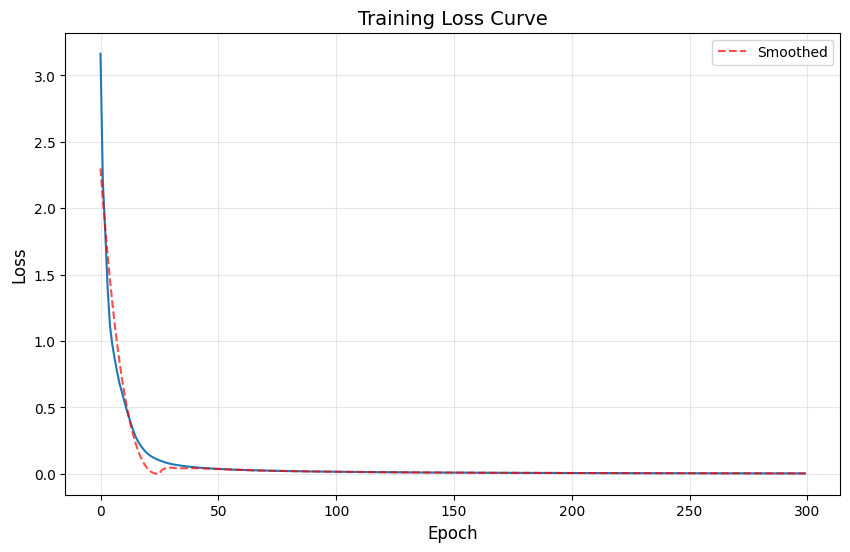


模型预测测试
输入: [3, 4, 5, 6]
预测: [3, 4, 5, 6, 7, 9, 10]
期望: [3, 4, 5, 6]
------------------------------
输入: [3, 4, 5, 6, 7]
预测: [3, 4, 5, 6, 7, 9, 10]
期望: [3, 4, 5, 6, 7]
------------------------------
输入: [8, 9, 10]
预测: [8, 9, 10]
期望: [8, 9, 10]
------------------------------
输入: [3, 5, 7, 9, 11]
预测: [3, 5, 7, 9, 11]
期望: [3, 5, 7, 9, 11]
------------------------------
输入: [4, 6, 8, 10]
预测: [4, 6, 8, 10]
期望: [4, 6, 8, 10]
------------------------------

最终验证：模型是否学会了复制任务？

序列预测准确率: 24/26 = 92.31%

✅ 成功！模型已经学会了复制任务！
   你的 Transformer 实现是正确的，可以用于实际任务了。


In [16]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# ========== 2. 创建模型和小数据集 ==========
def create_test_data():
    """
    创建一个简单的复制任务：模型需要学习将输入复制到输出
    例如：输入 [1,2,3,4] -> 输出 [1,2,3,4]
    """
    # 词汇表大小：假设 0=PAD, 1=BOS, 2=EOS, 3-10 是实际词
    vocab_size = 20
    padding_id = 0
    bos_id = 1
    eos_id = 2
    
    # 创建几个简单的句子对（源语言和目标语言相同）
    sentences = [
        [3, 4, 5, 6],
        [3, 4, 5, 6, 7],
        [8, 9, 10],
        [3, 5, 7, 9, 11],
        [4, 6, 8, 10]
    ]
    
    return sentences, vocab_size, padding_id, bos_id, eos_id

def prepare_batch(sentences, padding_id, bos_id, eos_id, max_len=None):
    """
    准备训练 batch：
    - encoder_input: 源语言句子（完整）
    - decoder_input: 目标语言句子（右移，加 BOS）
    - target: 目标语言句子（右移，加 EOS，用于计算损失）
    """
    if max_len is None:
        max_len = max(len(s) for s in sentences) + 1  # +1 for EOS/BOS
    
    batch_size = len(sentences)
    
    # Encoder input: 原始句子
    encoder_inputs = []
    for sent in sentences:
        padded = sent + [padding_id] * (max_len - 1 - len(sent))
        encoder_inputs.append(padded)
    encoder_inputs = torch.tensor(encoder_inputs)
    
    # Decoder input: [BOS] + 句子（去掉最后一个词，用于预测）
    decoder_inputs = []
    targets = []
    for sent in sentences:
        # decoder_input: BOS + 句子[:-1]
        dec_input = [bos_id] + sent[:-1]
        padded_dec = dec_input + [padding_id] * (max_len - len(dec_input))
        decoder_inputs.append(padded_dec)
        
        # target: 句子 + EOS
        target = sent + [eos_id]
        padded_target = target + [padding_id] * (max_len - len(target))
        targets.append(padded_target)
    
    decoder_inputs = torch.tensor(decoder_inputs)
    targets = torch.tensor(targets)
    
    return encoder_inputs, decoder_inputs, targets

# ========== 3. 训练函数 ==========
def train_model(model, train_sentences, vocab_size, padding_id, bos_id, eos_id, 
                num_epochs=200, lr=0.001, print_every=20):
    """
    训练模型并返回损失历史
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # 关键：ignore_index 忽略 padding 位置的损失
    criterion = nn.CrossEntropyLoss(ignore_index=padding_id)
    
    loss_history = []
    
    print(f"开始训练，共 {num_epochs} 个 epoch")
    print("="*50)
    
    for epoch in tqdm(range(num_epochs), desc="Training"):
        # 准备 batch（这里把所有数据作为一个 batch）
        encoder_inputs, decoder_inputs, targets = prepare_batch(
            train_sentences, padding_id, bos_id, eos_id
        )
        
        # 前向传播
        optimizer.zero_grad()
        output = model(encoder_inputs, decoder_inputs)
        
        # 计算损失
        # output shape: (batch, seq_len, vocab_size)
        # target shape: (batch, seq_len)
        loss = criterion(
            output.reshape(-1, vocab_size),
            targets.reshape(-1)
        )
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
        if epoch % print_every == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    
    print("="*50)
    print(f"训练完成！最终 Loss: {loss_history[-1]:.4f}")
    
    return loss_history

# ========== 4. 验证函数 ==========
def test_model(model, test_sentences, vocab_size, padding_id, bos_id, eos_id, max_len=10):
    """
    测试模型的预测能力（贪心解码）
    """
    model.eval()
    
    print("\n" + "="*50)
    print("模型预测测试")
    print("="*50)
    
    with torch.no_grad():
        for i, sent in enumerate(test_sentences):
            # 准备 encoder input
            encoder_input = torch.tensor([sent + [padding_id] * (max_len - len(sent))])
            
            # 初始 decoder input: [BOS]
            decoder_input = torch.tensor([[bos_id]])
            
            predicted = []
            for _ in range(max_len):
                # 预测下一个 token
                output = model(encoder_input, decoder_input)
                next_token_logits = output[0, -1, :]  # 最后一个位置的输出
                next_token = torch.argmax(next_token_logits).item()
                
                if next_token == eos_id:
                    break
                predicted.append(next_token)
                
                # 更新 decoder input
                decoder_input = torch.cat([
                    decoder_input, 
                    torch.tensor([[next_token]])
                ], dim=1)
            
            print(f"输入: {sent}")
            print(f"预测: {predicted}")
            print(f"期望: {sent}")
            print("-" * 30)

# ========== 5. 可视化损失曲线 ==========
def plot_loss(loss_history):
    """
    绘制训练损失曲线
    """
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history)
    plt.title('Training Loss Curve', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # 添加平滑曲线
    if len(loss_history) > 10:
        from scipy.signal import savgol_filter
        try:
            smoothed = savgol_filter(loss_history, min(51, len(loss_history)//2*2+1), 3)
            plt.plot(smoothed, 'r--', alpha=0.7, label='Smoothed')
            plt.legend()
        except:
            pass
    
    plt.show()

# ========== 6. 主执行流程 ==========
if __name__ == "__main__" or True:  # Jupyter 中直接运行
    print("="*50)
    print("Transformer 模型验证")
    print("="*50)
    
    # 创建数据
    train_sentences, vocab_size, padding_id, bos_id, eos_id = create_test_data()
    print(f"\n训练数据: {train_sentences}")
    print(f"词汇表大小: {vocab_size}")
    print(f"Padding ID: {padding_id}, BOS ID: {bos_id}, EOS ID: {eos_id}")
    
    # 模型参数（用较小的参数便于快速验证）
    head_num = 4
    head_dim = 16  # d_k = d_v
    d_model = head_num * head_dim  # 64
    num_layers = 3
    max_seq_len = 20
    num_embedding = vocab_size
    
    print(f"\n模型参数:")
    print(f"  - 头数: {head_num}")
    print(f"  - 头维度: {head_dim}")
    print(f"  - 模型维度: {d_model}")
    print(f"  - 编码器层数: {num_layers}")
    print(f"  - 解码器层数: {num_layers}")
    
    # 创建模型
    model = MyTransformer(
        head_num=head_num,
        num_layers=num_layers,
        d_model=d_model,
        head_dim=head_dim,
        num_embedding=num_embedding,
        max_seq_len=max_seq_len,
        padding_id=padding_id
    )
    
    # 打印参数量
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n模型参数量: {total_params:,} (可训练: {trainable_params:,})")
    
    # 训练模型
    loss_history = train_model(
        model=model,
        train_sentences=train_sentences,
        vocab_size=vocab_size,
        padding_id=padding_id,
        bos_id=bos_id,
        eos_id=eos_id,
        num_epochs=300,
        lr=0.001,
        print_every=50
    )
    
    # 可视化损失
    plot_loss(loss_history)
    
    # 测试模型
    test_model(
        model=model,
        test_sentences=train_sentences,  # 用训练集测试（应该能记住）
        vocab_size=vocab_size,
        padding_id=padding_id,
        bos_id=bos_id,
        eos_id=eos_id,
        max_len=15
    )
    
    # 额外测试：检查是否能记住训练数据
    print("\n" + "="*50)
    print("最终验证：模型是否学会了复制任务？")
    print("="*50)
    
    # 计算训练集上的准确率
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for sent in train_sentences:
            encoder_input = torch.tensor([sent + [padding_id] * (15 - len(sent))])
            decoder_input = torch.tensor([[bos_id]])
            
            for target_token in sent + [eos_id]:
                output = model(encoder_input, decoder_input)
                pred_token = torch.argmax(output[0, -1, :]).item()
                
                if pred_token == target_token:
                    correct += 1
                total += 1
                
                decoder_input = torch.cat([
                    decoder_input, 
                    torch.tensor([[pred_token]])
                ], dim=1)
                
                if pred_token == eos_id:
                    break
    
    accuracy = correct / total * 100
    print(f"\n序列预测准确率: {correct}/{total} = {accuracy:.2f}%")
    
    if accuracy > 80:
        print("\n✅ 成功！模型已经学会了复制任务！")
        print("   你的 Transformer 实现是正确的，可以用于实际任务了。")
    else:
        print("\n⚠️  准确率较低，可能需要调整参数或增加训练轮数。")
        print("   尝试增加 num_epochs 到 500 或调整学习率。")